In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


(11933, 13)
Age                  0
Gender               0
Height_cm            0
Weight_kg            0
Waist_cm             0
Hip_cm               0
Systolic_BP          0
Diastolic_BP         0
HbA1c                0
FBS                  0
Cholesterol_Total    0
HDL                  0
Diabetes_Status      0
dtype: int64


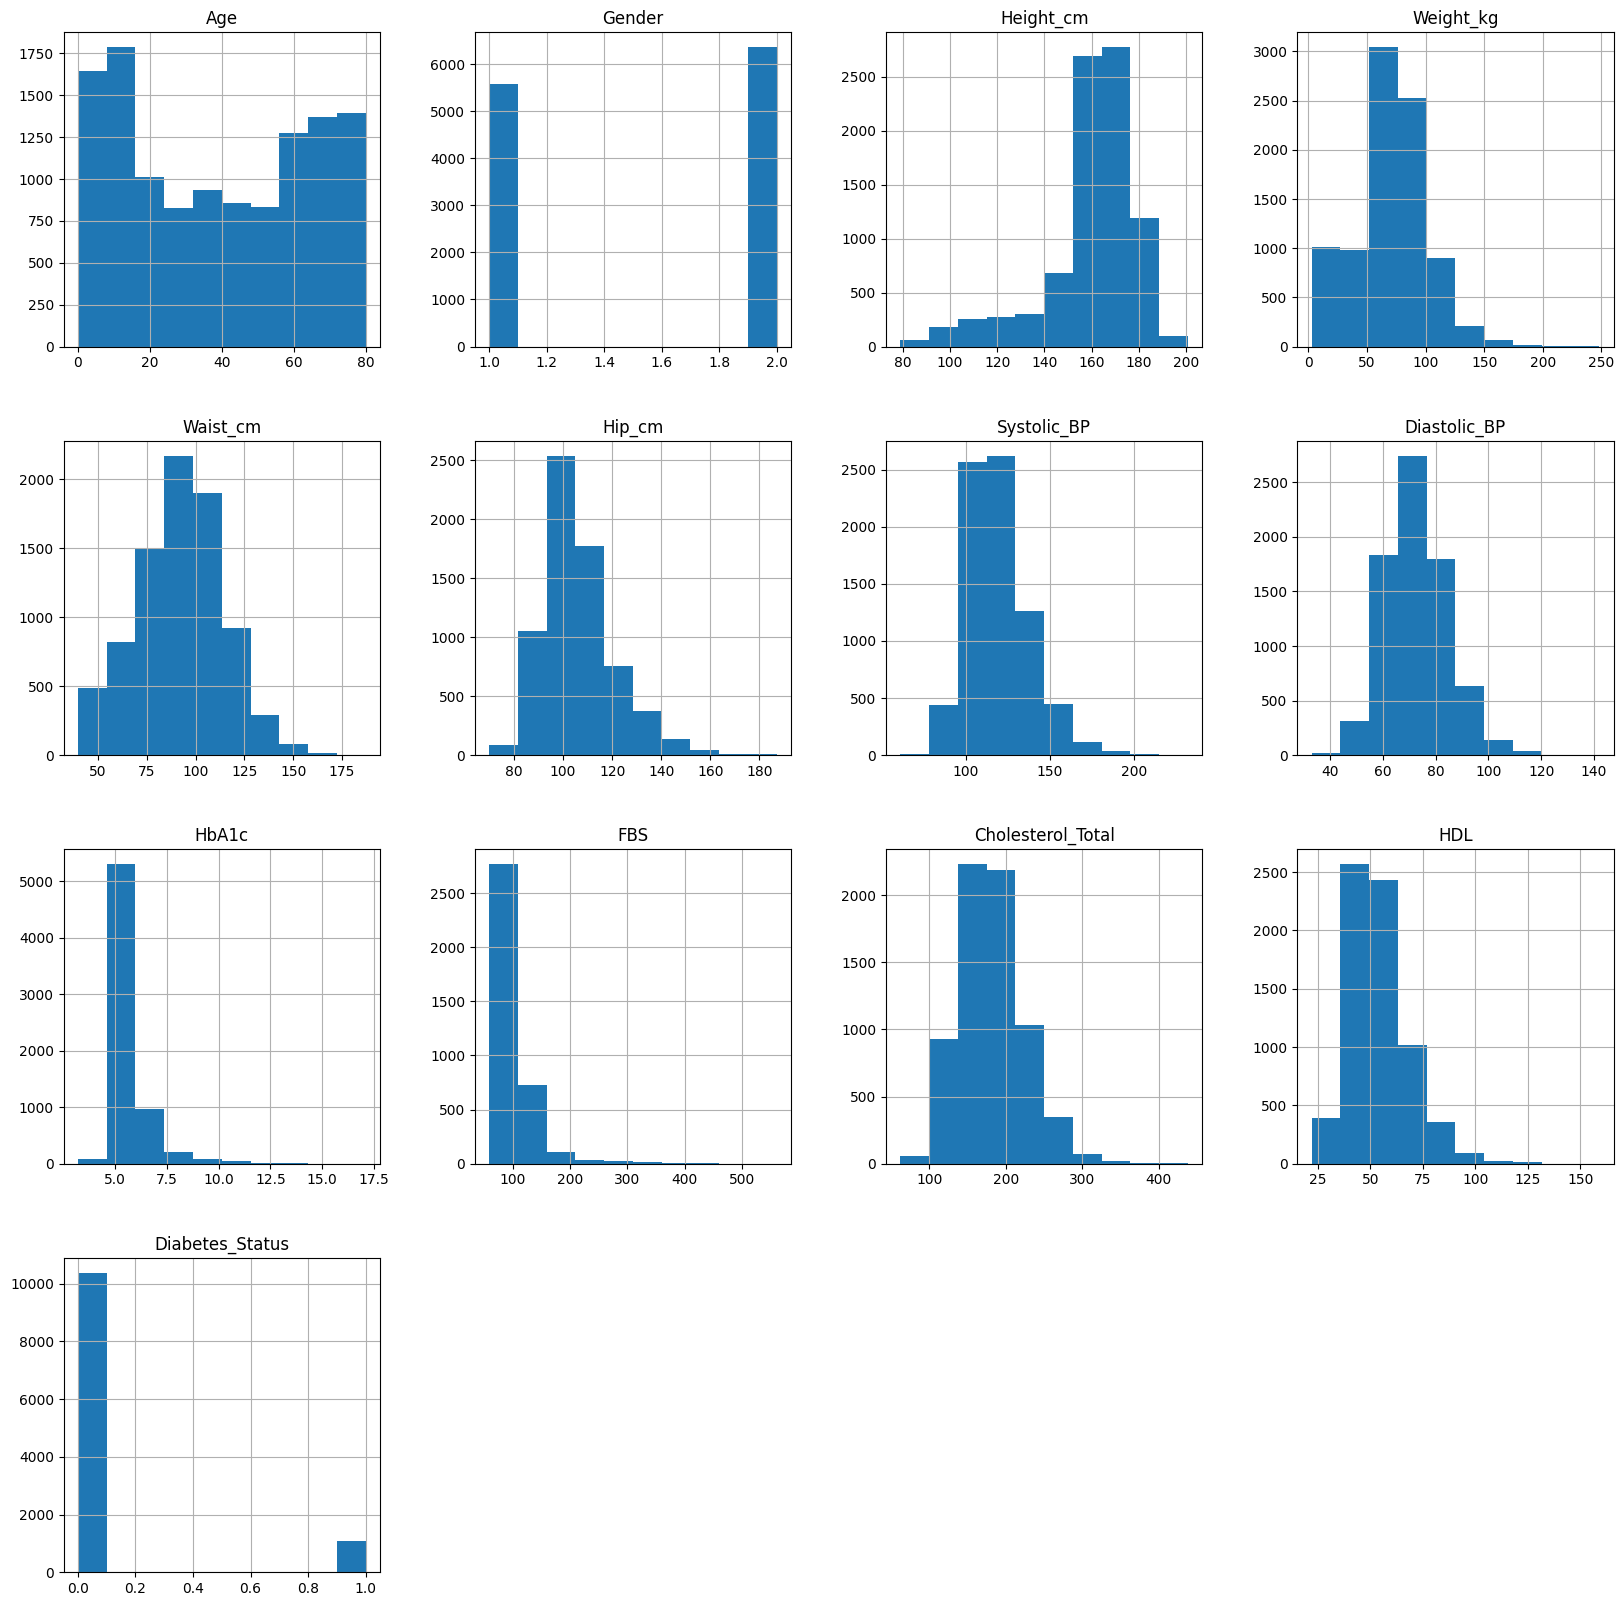

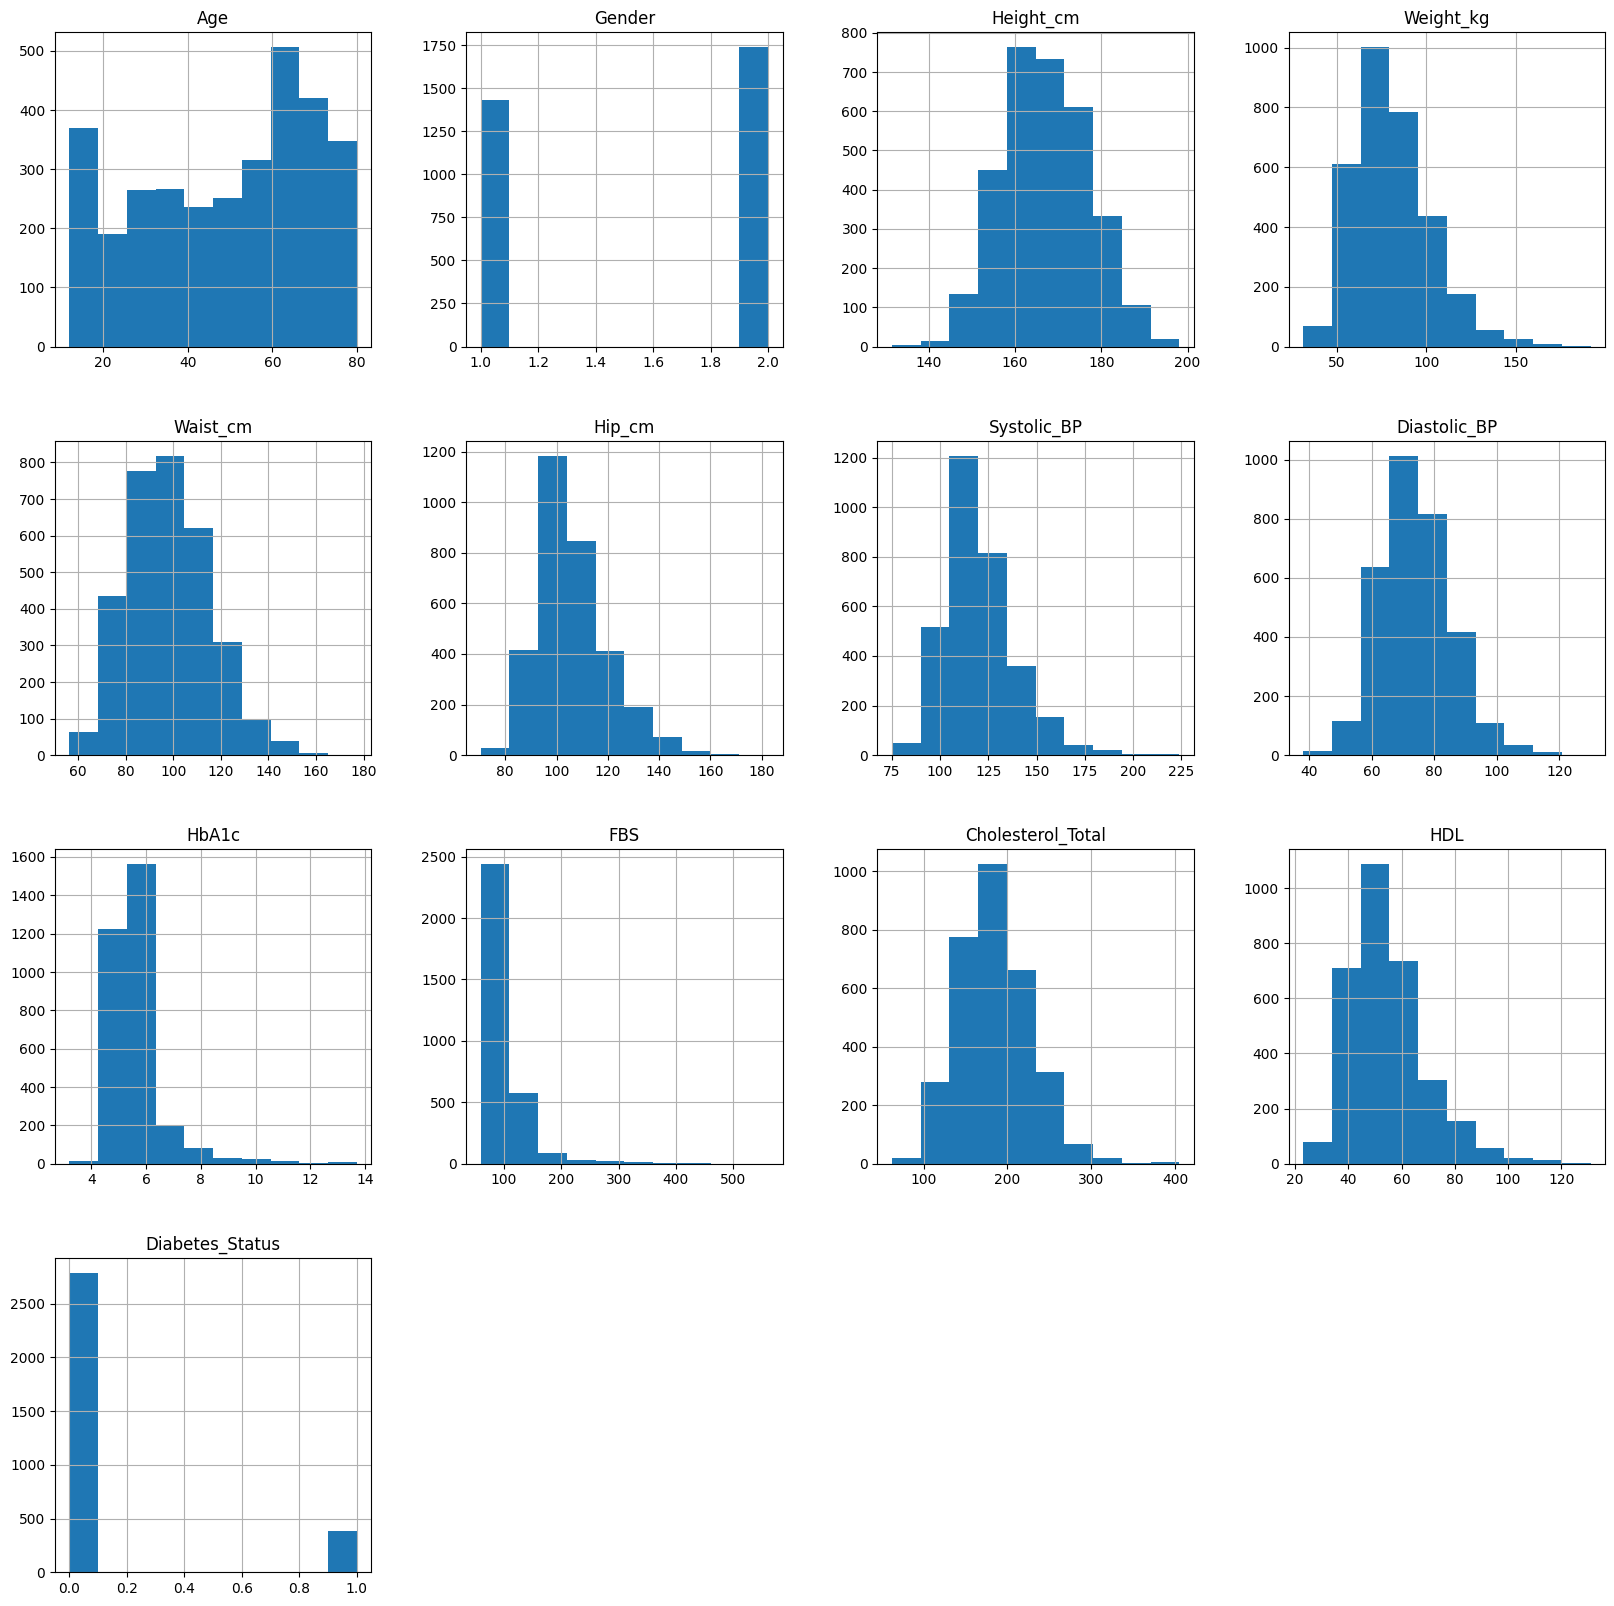

In [29]:
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
df.hist(figsize=(20,20))
# from tabulate import tabulate

# nulls = df.isnull().sum().reset_index()
# nulls.columns = ['Column', 'Missing Values']
# print(tabulate(nulls, headers='keys', tablefmt='psql'))
print(df.shape)

#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.hist(figsize=(20,20))
print(df_clean.isnull().sum())

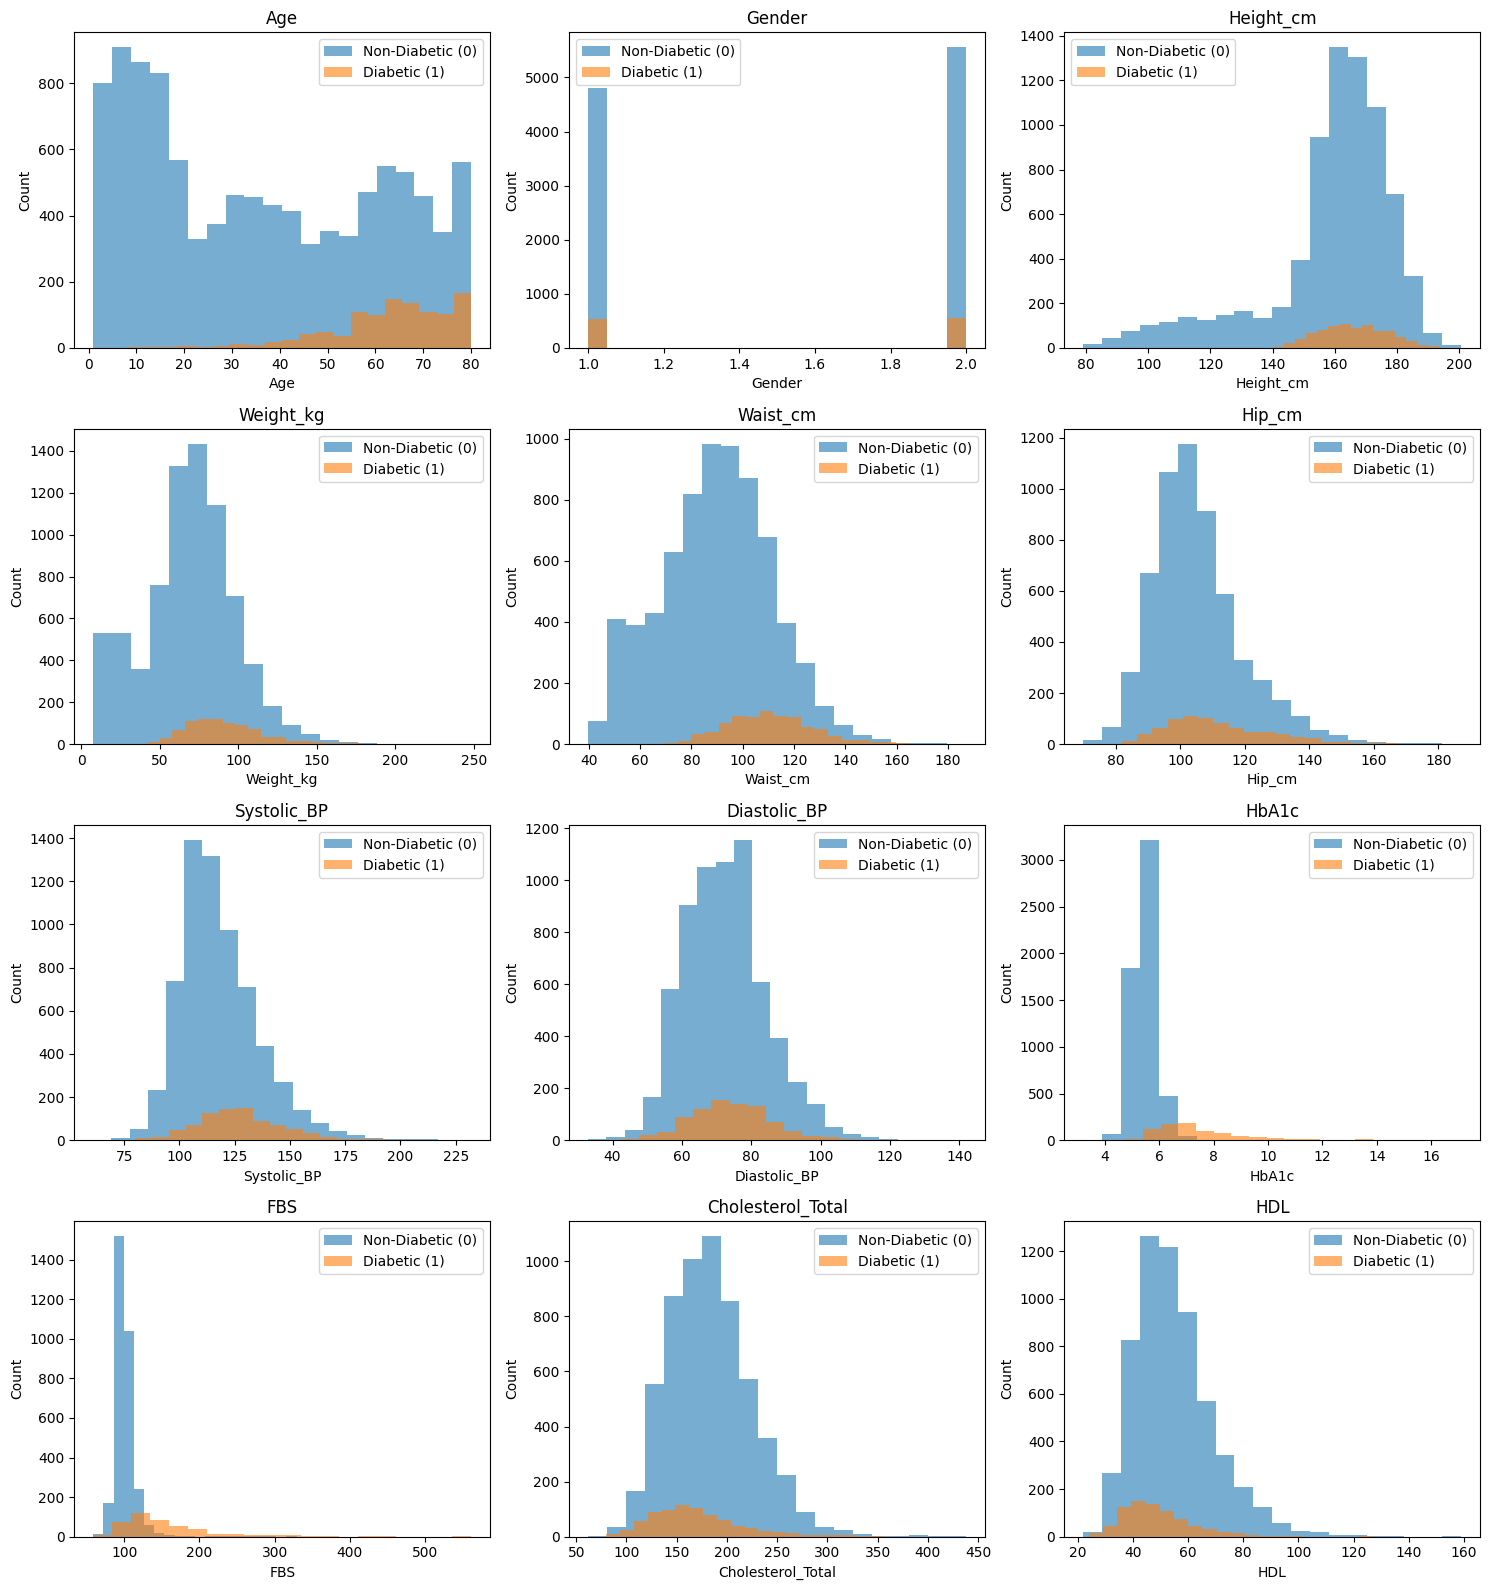

In [ ]:
import matplotlib.pyplot as plt

target = "Diabetes_Status"
features = df_clean.drop(columns=[target]).columns

# create grid: adjust rows/cols depending on number of features
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols  # auto rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()  # make axes iterable

for i, col in enumerate(features):
    ax = axes[i]
    df[df[target] == 0][col].plot(kind="hist", bins=20, alpha=0.6, label="Non-Diabetic (0)", ax=ax)
    df[df[target] == 1][col].plot(kind="hist", bins=20, alpha=0.6, label="Diabetic (1)", ax=ax)

    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

# remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("diabetes_distributions.png", dpi=300)  # save image
plt.show()


<Axes: >

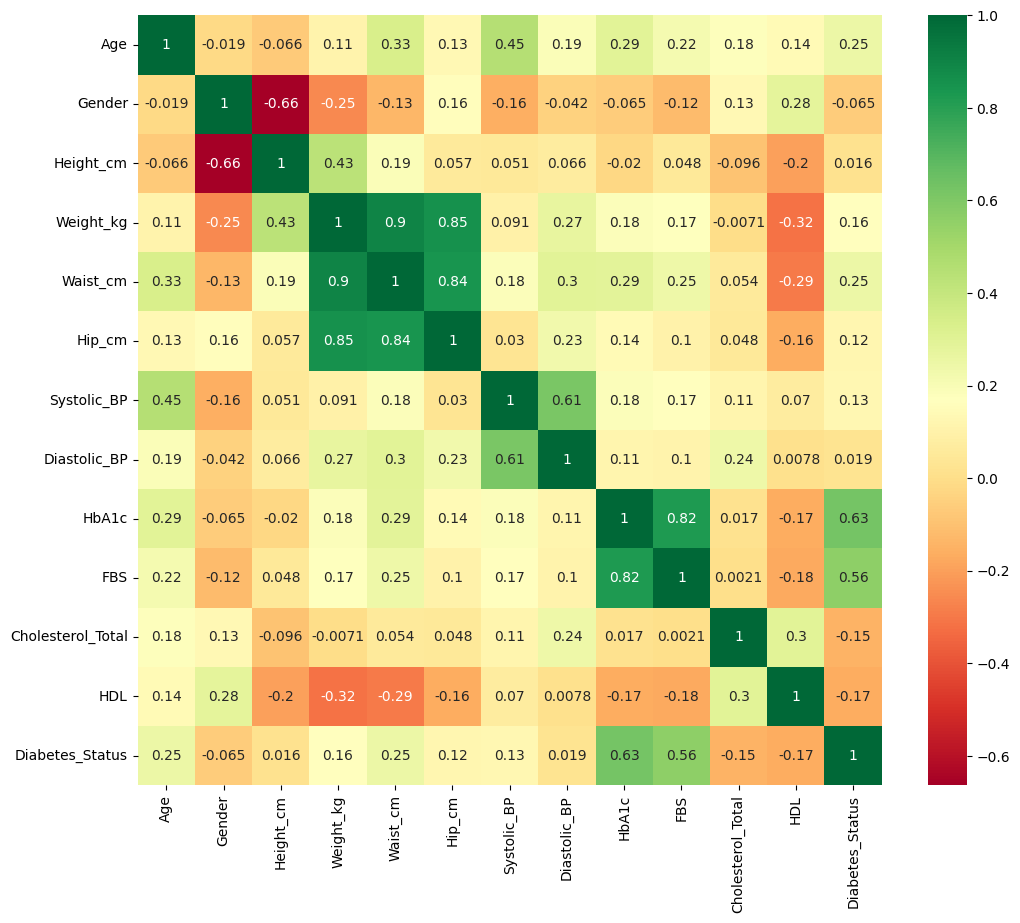

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdYlGn')

In [30]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Diabetes_Status"])
y = df_clean["Diabetes_Status"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print("Train ratio:\n", y_train.value_counts(normalize=True))
print("Valid ratio:\n", y_valid.value_counts(normalize=True))
print("Test ratio:\n", y_test.value_counts(normalize=True))


Train ratio:
 Diabetes_Status
0.0    0.879474
1.0    0.120526
Name: proportion, dtype: float64
Valid ratio:
 Diabetes_Status
0.0    0.879937
1.0    0.120063
Name: proportion, dtype: float64
Test ratio:
 Diabetes_Status
0.0    0.878549
1.0    0.121451
Name: proportion, dtype: float64


In [7]:
train = pd.DataFrame(X_train, columns=X.columns)
train["Diabetes_Status"] = y_train

valid = pd.DataFrame(X_valid, columns=X.columns)
valid["Diabetes_Status"] = y_valid

test = pd.DataFrame(X_test, columns=X.columns)
test["Diabetes_Status"] = y_test

In [8]:
train['Diabetes_Status'].value_counts()
valid['Diabetes_Status'].value_counts()
test['Diabetes_Status'].value_counts()


,count
Diabetes_Status,
0.0,557
1.0,77


# **Raw Dataset Training**
all values are raw that contains NaN.

GENDER:
*   MALE: 1,
*   FEMALE: 2

DIABETES STATS:
*   YES: 1
*   NO: 0





In [35]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

# Scale + oversample TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

ros = RandomOverSampler()
X_train_res, y_train_res = ros.fit_resample(X_train_scaled, y_train)


X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)



# Transform VALID and TEST using the same scaler (no fit again!)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)


In [ ]:
print(len(y_train[y_train==1]))
print(len(y_train[y_train==0]))


229
1671


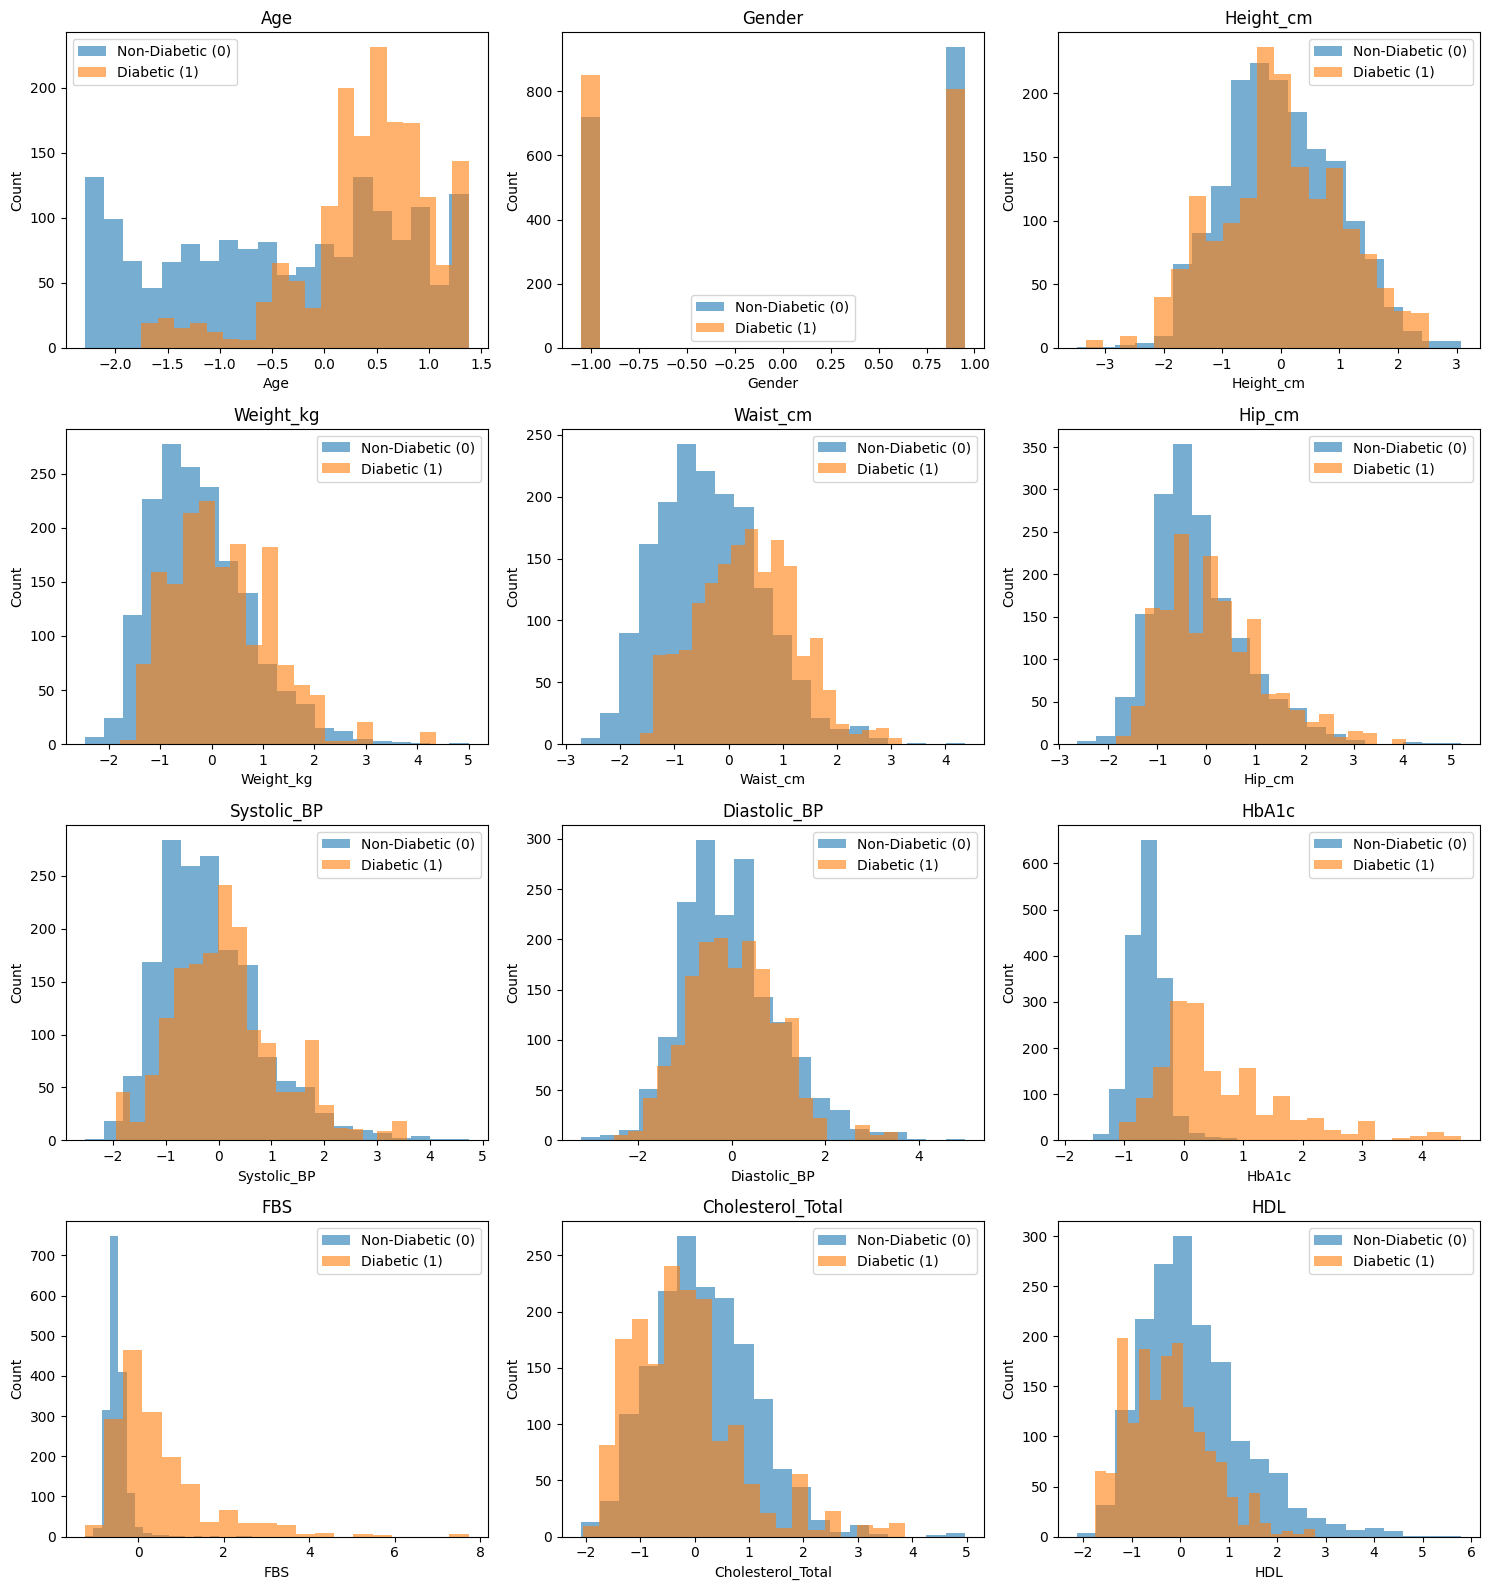

In [ ]:

import matplotlib.pyplot as plt

target = "Diabetes_Status"
features = train.drop(columns=[target]).columns

# create grid: adjust rows/cols depending on number of features
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols  # auto rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()  # make axes iterable

for i, col in enumerate(features):
    ax = axes[i]
    train[train[target] == 0][col].plot(kind="hist", bins=20, alpha=0.6, label="Non-Diabetic (0)", ax=ax)
    train[train[target] == 1][col].plot(kind="hist", bins=20, alpha=0.6, label="Diabetic (1)", ax=ax)

    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

# remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.savefig("diabetes_distributions.png", dpi=300)  # save image
plt.show()



K-NEAREST NEIGHBORS

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_res, y_train_res)

# PREDICTIONS
y_pred = knn_model.predict(X_test_scaled)


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.91      0.94       557
         1.0       0.54      0.79      0.65        77

    accuracy                           0.89       634
   macro avg       0.76      0.85      0.79       634
weighted avg       0.92      0.89      0.90       634



NAIVE BAYES

In [12]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model = nb_model.fit(X_train_res, y_train_res)

# PREDICTIONS
y_pred = nb_model.predict(X_test_scaled)

# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.94      0.95       557
         1.0       0.63      0.77      0.69        77

    accuracy                           0.92       634
   macro avg       0.80      0.85      0.82       634
weighted avg       0.93      0.92      0.92       634



LOGISTIC REGRESSION

In [13]:
from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression(max_iter=1000)
lg_model = lg_model.fit(X_train_res, y_train_res)

# PREDICTIONS
y_pred = lg_model.predict(X_test_scaled)

# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.91      0.94       557
         1.0       0.57      0.90      0.70        77

    accuracy                           0.91       634
   macro avg       0.78      0.90      0.82       634
weighted avg       0.93      0.91      0.92       634



SUPPORT VECTOR MACHINES

In [14]:
from sklearn.svm import SVC

# There are many params for this, tweak and try them
svm_model = SVC()
svm_model = svm_model.fit(X_train_res, y_train_res)

# PREDICTIONS
y_pred = svm_model.predict(X_test_scaled)

# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       557
         1.0       0.59      0.86      0.70        77

    accuracy                           0.91       634
   macro avg       0.78      0.89      0.82       634
weighted avg       0.93      0.91      0.92       634



RANDOM FORESTS

In [15]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=1, class_weight="balanced")
forest_model.fit(X_train_res, y_train_res)

# PREDICTIONS
y_pred = forest_model.predict(X_valid_scaled)

# CLASSIFICATION REPORT
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       557
         1.0       0.77      0.78      0.77        76

    accuracy                           0.94       633
   macro avg       0.87      0.87      0.87       633
weighted avg       0.95      0.94      0.94       633



In [ ]:
from sklearn.metrics import mean_absolute_error
preds_val = forest_model.predict(X_valid)
mae = mean_absolute_error(y_valid, preds_val)
print(mae)

0.12006319115323855


In [16]:
from math import nan
#new_patient = [[57, 1, 183.2, 109.4, 117.8, 107.3, 110, 66, 7.2, 179, 126, 31]]
new_patient = [[nan, nan, nan, nan, nan, nan, nan, nan, 4.2, 179, nan, nan]]


# Scale using the SAME scaler fitted on training data
new_patient_scaled = scaler.transform(new_patient)

# Predict class (0 or 1)
prediction = forest_model.predict(new_patient_scaled)
print("Prediction:", prediction[0])  # 0 = No diabetes, 1 = Diabetes

# Predict probability
prob = forest_model.predict_proba(new_patient_scaled)
print("Probabilities:", prob)
print("Probability of diabetes:", prob[0][1])

Prediction: 0.0
Probabilities: [[0.53 0.47]]
Probability of diabetes: 0.47


# Feature Importance

Gini Importance

              Feature  Gini Importance
8               HbA1c         0.388754
9                 FBS         0.194397
0                 Age         0.094310
4            Waist_cm         0.057564
10  Cholesterol_Total         0.053299
11                HDL         0.041388
2           Height_cm         0.038546
3           Weight_kg         0.037479
6         Systolic_BP         0.032718
5              Hip_cm         0.030412
7        Diastolic_BP         0.026376
1              Gender         0.004757


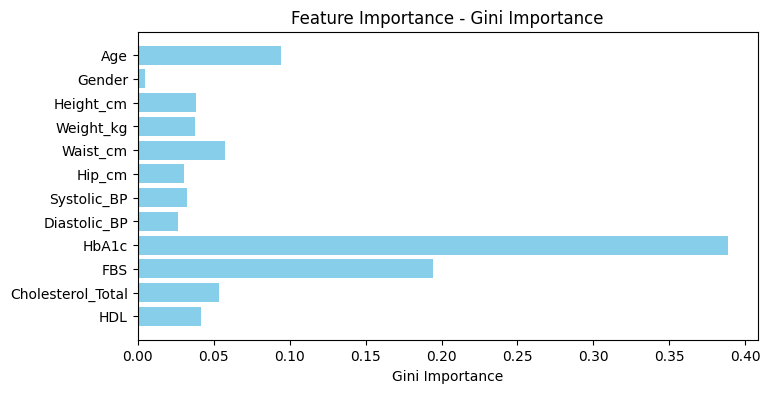

In [ ]:
import shap
feature_names = df_clean.columns[:-1]
importances = forest_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
print(feature_imp_df)

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, f1_score

In [36]:
numeric_features = X_train_res.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)

print(numeric_features)

['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm', 'Systolic_BP', 'Diastolic_BP', 'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL']


In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [37]:

def train_and_evaluate_model(models, X_train_res, y_train_res, X_valid_scaled, y_valid):

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        if name == "Random Forest" or name == "XGBoost":
          pipe = ImbPipeline([
              ('oversample', RandomOverSampler()),
              ('model', model)
          ])
        else:
          pipe = ImbPipeline([
              ('preprocess', preprocessor),
              ('oversample', RandomOverSampler()),
              ('model', model)
          ])

        pipe.fit(X_train_res, y_train_res)

        y_pred = pipe.predict(X_valid_scaled)
        y_proba = pipe.predict_proba(X_valid_scaled)[:, 1]

        print(roc_auc_score(y_valid, y_proba))
        print(classification_report(y_valid, y_pred, digits=2))

        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

train_and_evaluate_model(models, X_train_res, y_train_res, X_valid_scaled, y_valid)



🔹 Training Logistic Regression...


ValueError: Specifying the columns using strings is only supported for dataframes.


🔹 Training Logistic Regression 2...
0.9700935462534253
              precision    recall  f1-score   support

         0.0       0.99      0.90      0.94       557
         1.0       0.56      0.96      0.71        76

    accuracy                           0.90       633
   macro avg       0.78      0.93      0.82       633
weighted avg       0.94      0.90      0.91       633



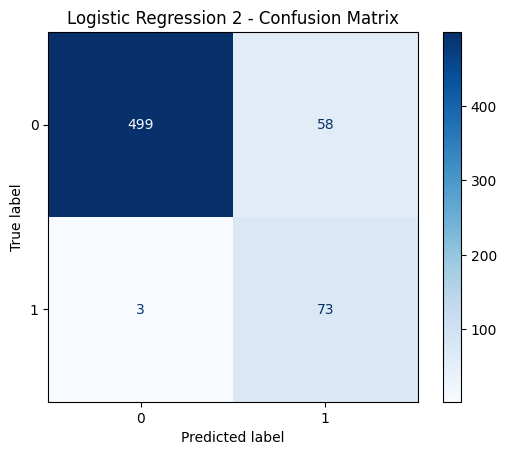

In [26]:
models_lg = {
    "Logistic Regression 2": LogisticRegression(max_iter=1000, random_state=42, penalty='l2', C=0.1, class_weight='balanced'),
}

train_and_evaluate_model(models_lg, X_train_res, y_train_res, X_valid, y_valid)


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC-AUC: 0.956083230803564


In [ ]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Gender', 'Height_cm',
                                                   'Weight_kg', 'Waist_cm',
                                                   'Hip_cm', 'Systolic_BP',
                                                   'Diastolic_BP', 'HbA1c',
                                                   'FBS', 'Cholesterol_Total',
                                                   'HDL'])])),
                ('model',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

In [ ]:
new_patient = pd.DataFrame([{
    'Age': 45,
    'Gender': 1,
    'Height_cm': 179.5,
    'Weight_kg': 86.9,
    'Waist_cm': 98.3,
    'Hip_cm': 102.9,
    'Systolic_BP': 135,
    'Diastolic_BP': 98,
    'HbA1c': 5.6,
    'FBS': 113,
    'Cholesterol_Total': 264,
    'HDL': 45
}])

prob = best_pipe.predict_proba(new_patient)[0]
print(f"Predicted Probability of No Diabetes: {prob[0]*100:.2f}%")
print(f"Predicted Probability of Diabetes: {prob[1]*100:.2f}%")




Predicted Probability of No Diabetes: 92.06%
Predicted Probability of Diabetes: 7.94%


# Pipelines

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

In [ ]:
X = df_clean.drop(columns=["Diabetes_Status"])
y = df_clean["Diabetes_Status"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

new_patient = [[52, 1, 174.9, 84.4, 95.9, 96.4, 115, 72, 4.9, 97, 178, 31]]


In [ ]:
print(y_test.value_counts())

Diabetes_Status
0.0    418
1.0     58
Name: count, dtype: int64


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [ ]:
results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('oversample', RandomOverSampler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_valid)
    y_proba = pipe.predict_proba(X_valid)[:, 1]

    auc = roc_auc_score(y_valid, y_proba)
    print(f"{name} ROC AUC: {auc:.3f}")
    print(classification_report(y_valid, y_pred))

    results[name] = {"pipeline": pipe, "roc_auc": auc}

    new_patient = [[42, 2, 120, 80, 169.2, 121, 115, 72, 4.9, 97, 178, 31]]

    pred_class = pipe.predict(new_patient)[0]
    pred_proba = pipe.predict_proba(new_patient)[0]

    print(f" New Patient Prediction ({name}): {pred_class}")
    print(f" Probability of Diabetes: {pred_proba[0]:.3f} {pred_proba[1]:.3f}")
    print("\nBalanced y_train after oversampling:")
    print(pipe.named_steps['oversample'].fit_resample(X_train, y_train)[1].value_counts())




🔹 Training Logistic Regression...
Logistic Regression ROC AUC: 0.970
              precision    recall  f1-score   support

         0.0       0.99      0.90      0.94       418
         1.0       0.56      0.93      0.70        57

    accuracy                           0.90       475
   macro avg       0.77      0.91      0.82       475
weighted avg       0.94      0.90      0.91       475

 New Patient Prediction (Logistic Regression): 1.0
 Probability of Diabetes: 0.270 0.730

Balanced y_train after oversampling:
Diabetes_Status
0.0    1949
1.0    1949
Name: count, dtype: int64

🔹 Training Random Forest...
Random Forest ROC AUC: 0.968
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       418
         1.0       0.80      0.75      0.77        57

    accuracy                           0.95       475
   macro avg       0.88      0.86      0.87       475
weighted avg       0.95      0.95      0.95       475

 New Patient Prediction (

kNN pipe

In [ ]:
knn_pipe = Pipeline([
    ('scaler', )
])